In [9]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("insurance.csv")

df.head(10)

Saving insurance.csv to insurance (1).csv


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [10]:
df.shape

(1338, 7)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [13]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [14]:
# Numerical columns
numerical = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:")
print(numerical)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')


In [15]:
# Categorical columns
categorical = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical)


Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

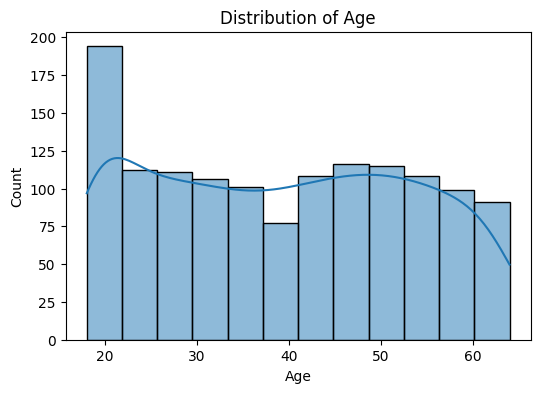

In [17]:
#Age
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

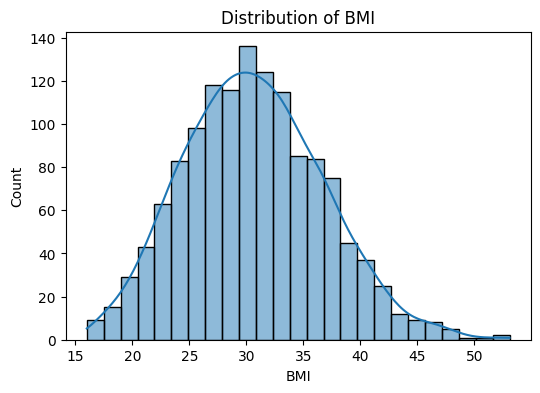

In [18]:
# BMI
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()


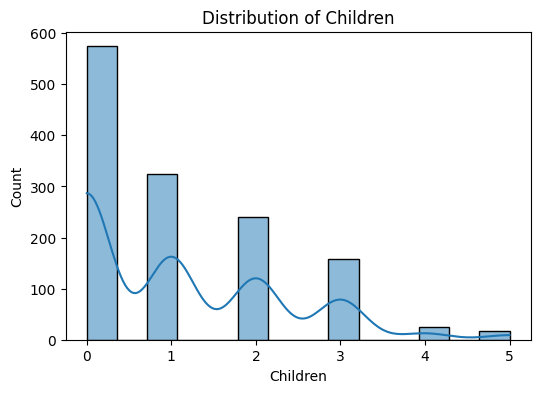

In [19]:
# Children
plt.figure(figsize=(6,4))
sns.histplot(df['children'], kde=True)
plt.title("Distribution of Children")
plt.xlabel("Children")
plt.ylabel("Count")
plt.show()


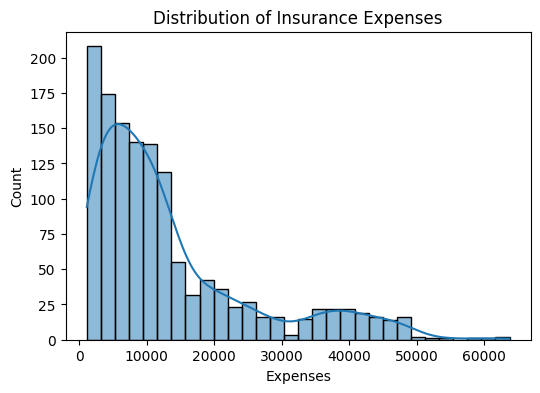

In [23]:
# Expenses
plt.figure(figsize=(6,4))
sns.histplot(df['expenses'], kde=True)
plt.title("Distribution of Insurance Expenses")
plt.xlabel("Expenses")
plt.ylabel("Count")
plt.show()


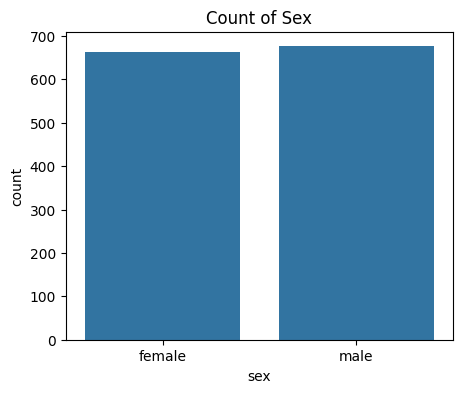

In [24]:
# Sex
plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=df)
plt.title("Count of Sex")
plt.show()


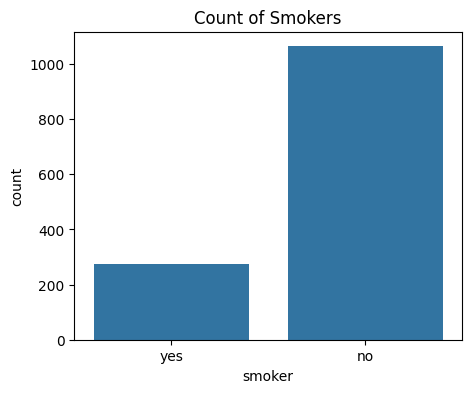

In [25]:
# Smoker
plt.figure(figsize=(5,4))
sns.countplot(x='smoker', data=df)
plt.title("Count of Smokers")
plt.show()

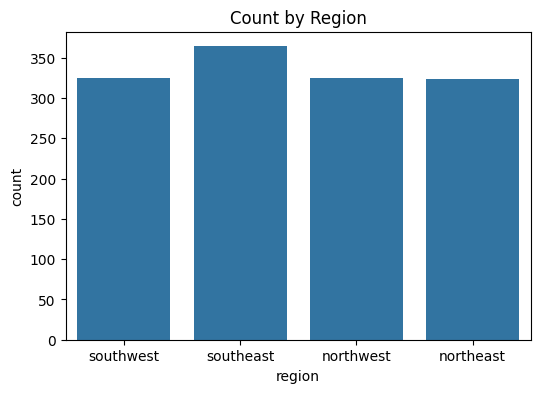

In [26]:
# Region
plt.figure(figsize=(6,4))
sns.countplot(x='region', data=df)
plt.title("Count by Region")
plt.show()

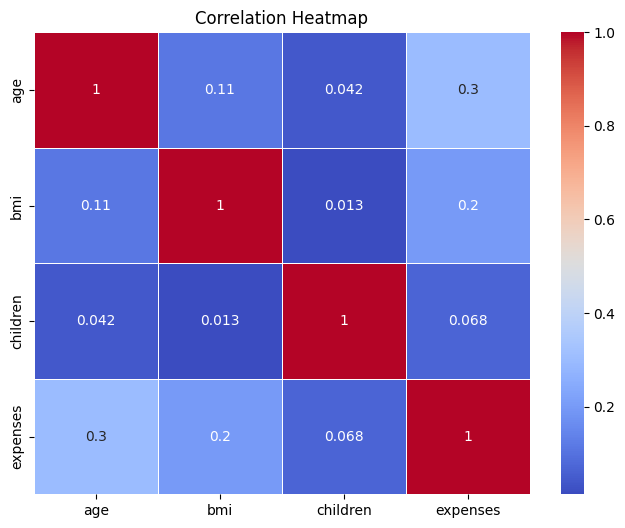

In [27]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
# Average expenses
print("Average Expenses:", df['expenses'].mean())

# Maximum expenses
print("Maximum Expenses:", df['expenses'].max())

# Minimum expenses
print("Minimum Expenses:", df['expenses'].min())

# Average expenses of smokers vs non-smokers
print(df.groupby('smoker')['expenses'].mean())

Average Expenses: 13270.422414050823
Maximum Expenses: 63770.43
Minimum Expenses: 1121.87
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


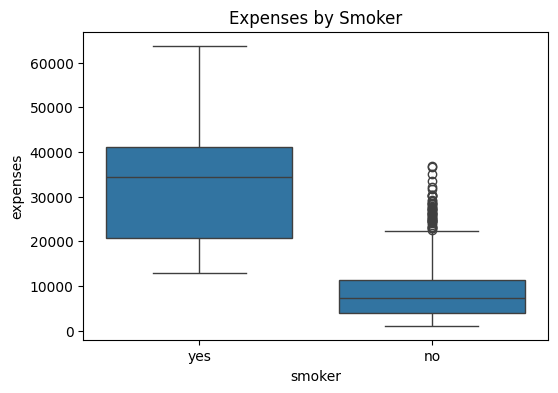

In [29]:
# Expenses vs Smoker
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Expenses by Smoker")
plt.show()

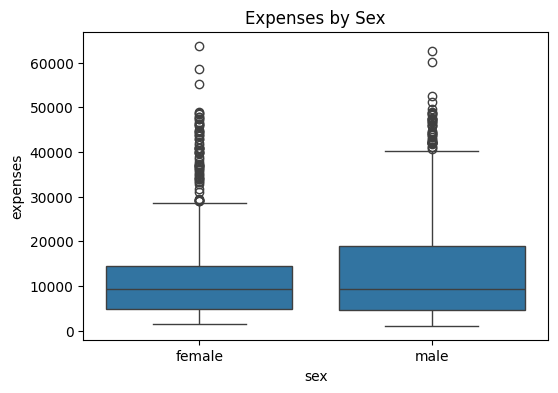

In [30]:
# Expenses vs Sex
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='expenses', data=df)
plt.title("Expenses by Sex")
plt.show()

# Analysis Summary

# 1. Average Age and BMI
# Average Age: 39.21 years
# Average BMI: 30.67

# 2. Smoking Effect
# Smokers have much higher insurance expenses than non-smokers.
# Average expenses:
# Smokers: 32050.23
# Non-Smokers: 8434.27

# 3. Region with Highest Customers
# Southeast (364 customers)

# 4. Interesting Observations
# - Most customers are adults.
# - BMI is centered around 30.
# - Expenses are right-skewed because a few customers have very high expenses.
# - Smoking has the strongest effect on insurance expenses.
# - Male and female expenses are fairly similar.